# 📊 Plotting for Machine Learning

📂 `Titanic-Dataset.csv` and `mpg.csv` — keep both in this folder.

Every plot today answers **one question**, and the answer changes what you do next.

**How many columns am I looking at?**

| columns | called | today |
|---|---|---|
| 1 | univariate | `histplot` · `countplot` |
| 2 | bivariate | `boxplot` · `scatterplot` · `hue=` |
| 3+ | multivariate | `pairplot` · `heatmap` |

In [3]:
! pip3 install matplotlib
! pip3 install seaborn




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/ankit/BOX 1/B1 ROOM 1/AI&ML/Class6/test.csv')   # demo
mpg = pd.read_csv('/Users/ankit/BOX 1/B1 ROOM 1/AI&ML/class10/mpg.csv')               # your practice

print(df.shape, mpg.shape)
df.head()

(418, 11) (398, 9)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


---
## Why plot at all

On Day 5 you found `Fare` has mean **32.20** and median **14.45**, and you filled with the
median because the mean looked wrong.

Today you will see *why* in one picture.

---
## 0️⃣ The matplotlib skeleton

Three lines around every plot:

```python
plt.figure(figsize=(7, 4))   # size
sns.something(...)           # the plot
plt.title('...')             # label it
plt.show()
```

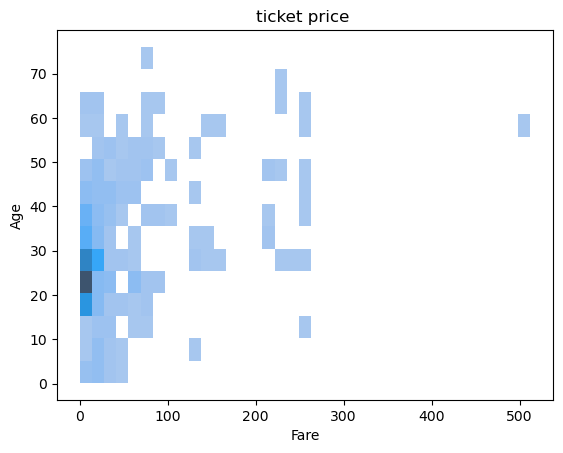

In [18]:
# a plain histogram of Fare, with a size and a title -> histplot 
plt.Figure(figsize=(7,4))
sns.histplot(data=df,x='Fare',y="Age")
plt.title("ticket price ")
plt.show()

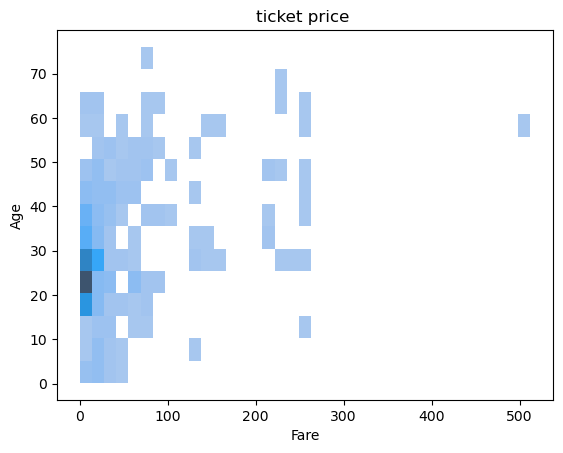

In [20]:
# save that same chart as a file
plt.Figure(figsize=(7,4))
sns.histplot(data=df,x='Fare',y="Age")
plt.title("ticket price ")
plt.show()

`plt.savefig('name.png')` must come **before** `plt.show()` — after it, the figure is gone.

---
# 1️⃣ Univariate — one column at a time

**The question:** can I use this feature at all?

### `histplot` — how is one number spread out?

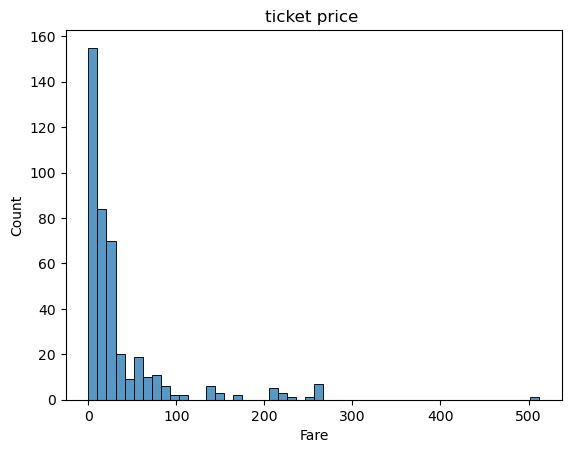

In [33]:
# distribution of Fare
plt.Figure(figsize=(12,12))
sns.histplot(data=df,x='Fare',bins=50)
plt.title("ticket price ")
plt.show()

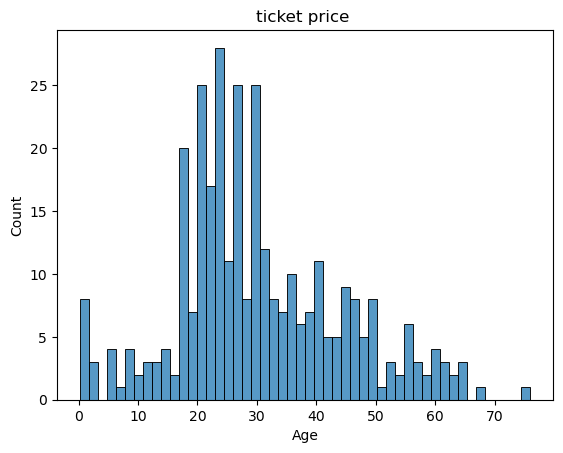

In [34]:
# distribution of Age
plt.Figure(figsize=(12,12))
sns.histplot(data=df,x='Age',bins=50)
plt.title("ticket price ")
plt.show()

| | mean | median | max |
|---|---|---|---|
| Fare | 32.20 | **14.45** | 512 |
| Age | 29.70 | 28.00 | 80 |

`Fare` has a long tail to the right — a few people paid enormous amounts and dragged the
mean above the median. `Age` is roughly symmetric.

⭐ **The shape decides your fill.** Long tail → median. Symmetric → either works.

### `countplot` — how many in each category?

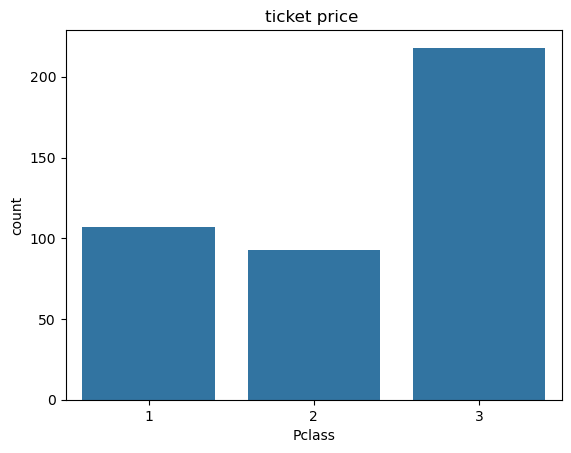

In [41]:
# how many survived and how many died
plt.Figure(figsize=(12,13))
sns.countplot(data=df,x='Pclass')
plt.title("ticket price ")
plt.show()

**549 died, 342 survived** — that is **61.6%**.

⭐ A model that always predicts "died" scores 61.6% without learning anything.
Any accuracy below that is worse than saying nothing.

### 🧩 Try these — on `mpg.csv`

**Q1** Plot the distribution of `mpg`. Is it skewed? If this column had blanks, would you
fill with the mean or the median?

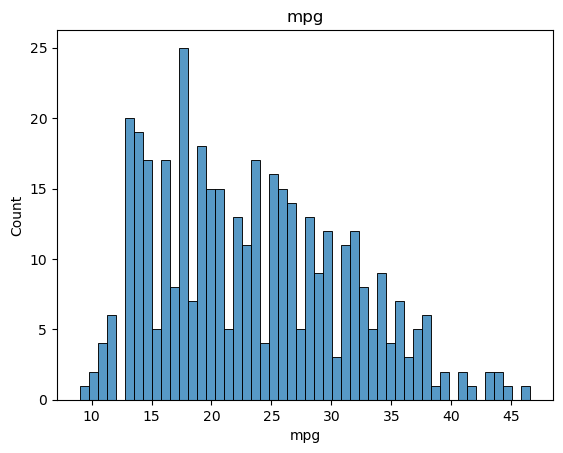

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [44]:
# Q1
mpg.head()
plt.Figure(figsize=(12,12))
sns.histplot(data=mpg,x='mpg',bins=50)
plt.title("mpg")
plt.show()

mpg.head()

**Q2** How many cars come from each `origin`? What would that imbalance do to a model
trained on this data?

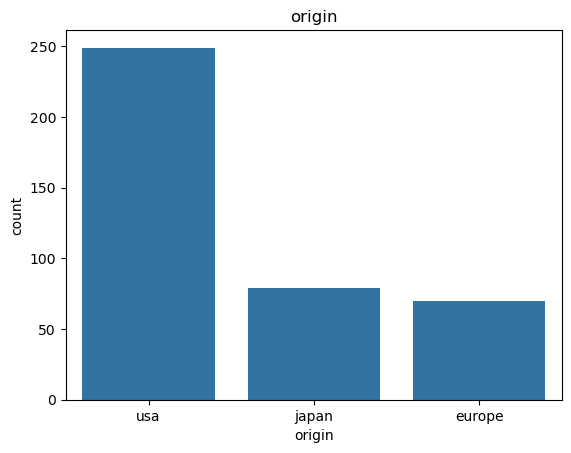

In [ ]:
# Q2plt.Figure(figsize=(12,12))
plt.Figure(figsize=(12,12))
sns.countplot(data=mpg,x='origin')
plt.title("origin")
plt.show()


---
# 2️⃣ Bivariate — two columns together

**The question:** does this feature separate the thing I am predicting?

### `boxplot` — does a number differ across groups?

In [ ]:
# Fare on its own — read the box, the whiskers, the dots


The box is the middle half of the data. The line inside is the median. The dots beyond the
whiskers are outliers — `Fare` has **116** of them.

In [ ]:
# Fare split by Survived


In [ ]:
# Age split by Survived


| | died | survived |
|---|---|---|
| median `Fare` | 10.50 | **26.00** |
| median `Age` | 28.0 | 28.0 |

⭐ `Fare` separates the two groups. `Age` does not. **A feature that does not separate
your classes will not help your model.**

### `scatterplot` — do two numbers move together?

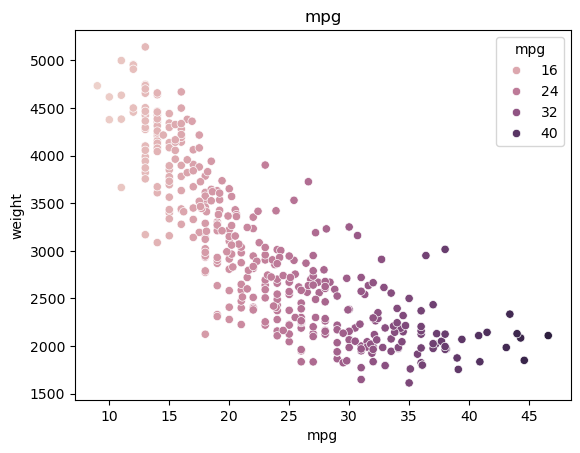

In [52]:
# Age against Fare
plt.Figure(figsize=(12,12))
sns.scatterplot(data=mpg,x='mpg',y="weight",hue="mpg")
plt.title("mpg")
plt.show()

A shapeless cloud. These two columns barely relate — the correlation is only 0.096.

### `hue=` — the argument that turns any plot into an ML plot

Add one word and the target appears inside the picture.

In [ ]:
# the same scatter, coloured by Survived


In [ ]:
# and a countplot of Pclass, coloured by Survived


The scatter now shows where survivors sit. The countplot shows both the survival split
**and** the group sizes at once — 216, 184, **491**.

⭐ That is the "read the group size next to the group average" rule from last week,
drawn instead of calculated.

### 🧩 Try these — on `mpg.csv`

**Q3** Boxplot `mpg` split by `origin`, then split by `cylinders` instead.
Which of the two separates the groups more clearly?

In [ ]:
# Q3

**Q4** Scatter `weight` against `mpg`, coloured by `origin`.
Describe the relationship in one line, and say what the colours add.

In [ ]:
# Q4


---
# 3️⃣ Multivariate — everything at once

**The question:** which features matter, and which ones repeat each other?

### `pairplot` — every pair of columns in one grid

In [ ]:
# pairplot of Age, Fare, Pclass and Survived, coloured by Survived



In [ ]:
# pairplot of total_bil,age and size diag_kind is hist colored by sex

Scatter plots off the diagonal, distributions along it. Univariate and bivariate in a
single line.

⚠️ `pairplot` builds its own figure, so `plt.figure(figsize=...)` has no effect on it.
Use `height=` instead. It is also slow on wide tables — pick your columns first.

### `heatmap` — the same idea as numbers

In [ ]:
# correlation of the numeric columns


In [ ]:
# the same thing as a heatmap, with the numbers written on it

Correlation with `Survived`:

| feature | correlation |
|---|---|
| `Pclass` | **−0.34** |
| `Fare` | 0.26 |
| `Parch` | 0.08 |
| `Age` | −0.08 |

⭐ A heatmap does two jobs: it shows **what predicts your target**, and it shows
**which features are duplicates of each other**.

### 🧩 Try this — on `mpg.csv`

**Q5** ⭐ Heatmap of the numeric columns in `mpg`. Two parts:

1. Which feature predicts `mpg` best?
2. Find two features that are almost the same thing — if you had to drop one, which
   and why?

In [ ]:
# Q5

---
## 📌 Which plot, when

| Your question | Columns | Plot |
|---|---|---|
| How is one number spread out? | 1 numeric | `histplot` |
| How many in each category? | 1 categorical | `countplot` |
| Does this number differ across groups? | numeric + categorical | `boxplot` |
| Do two numbers move together? | 2 numeric | `scatterplot` |
| *…and does the target split them?* | **+ target** | **add `hue=`** |
| Quick look at everything | many numeric | `pairplot` |
| Which features matter, which repeat? | many numeric | `heatmap` |

### The skeleton
```python
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='column')
plt.title('...')
plt.show()
```

### What each plot decided today
- `Fare` is skewed → **fill with the median**
- 61.6% died → **any model must beat 61.6%**
- `Fare` separates survivors, `Age` does not → **keep Fare, question Age**
- `Pclass` correlates −0.34 with survival → **the strongest single number you have**